In [216]:
#Load all the different data frames 
import pandas as pd 



df_titanic = pd.read_csv('C:/Users/noura/ml-disaster-survival-project/data/external/Titanic.csv', sep=',')
df_lusitania= pd.read_csv('C:/Users/noura/ml-disaster-survival-project/data/raw/lusitania_people_1915_all_tables.csv')
df_estonia= pd.read_csv('C:/Users./noura/ml-disaster-survival-project/data/external/estonia-passenger-list.csv')

# EXPLORATION DES DONNEES

In [217]:
import pandas as pd
import numpy as np

def eda_basic(df: pd.DataFrame, name: str, target_col: str | None = None, head_n: int = 5, top_k: int = 10):
    print("\n" + "="*100)
    print(f"EDA — {name}")
    print("="*100)

    # 1) Aperçu
    print(f"\nShape (lignes, colonnes): {df.shape}")
    print("\nAperçu (head):")
    display(df.head(head_n))

    # 2) Colonnes + types
    print("\nColonnes:")
    print(list(df.columns))

    print("\nTypes de données (dtypes):")
    display(df.dtypes.to_frame("dtype"))

    # 3) Infos générales
    print("\nInfo générale (mémoire, non-null, etc.):")
    df.info()

    # 4) Doublons
    n_dup = df.duplicated().sum()
    print(f"\nDoublons (lignes dupliquées): {n_dup}")

    # 5) Valeurs manquantes
    missing_count = df.isna().sum()
    missing_pct = (df.isna().mean() * 100).round(2)
    missing_table = pd.DataFrame({
        "missing_count": missing_count,
        "missing_pct": missing_pct
    }).sort_values("missing_pct", ascending=False)

    print("\nValeurs manquantes par colonne:")
    display(missing_table)

    # 6) Statistiques numériques
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    print(f"\nColonnes numériques ({len(num_cols)}): {num_cols}")
    if len(num_cols) > 0:
        print("\nStatistiques numériques (describe):")
        display(df[num_cols].describe().T)

        print("\nMoyennes des colonnes numériques:")
        display(df[num_cols].mean(numeric_only=True).to_frame("mean"))

    # 7) Statistiques catégorielles
    cat_cols = df.select_dtypes(include=["object", "string", "category", "bool"]).columns.tolist()
    print(f"\nColonnes catégorielles/bool ({len(cat_cols)}): {cat_cols}")
    if len(cat_cols) > 0:
        print("\nStatistiques catégorielles (describe):")
        display(df[cat_cols].describe().T)

        # Top valeurs pour chaque colonne catégorielle
        print(f"\nTop {top_k} valeurs par colonne catégorielle:")
        for c in cat_cols:
            print("\n" + "-"*80)
            print(f"{c} — top valeurs")
            vc = df[c].astype("string").fillna("NA").value_counts().head(top_k)
            display(vc.to_frame("count"))

    # 8) Vérifs rapides utiles (outliers simples, valeurs aberrantes)
    if len(num_cols) > 0:
        print("\nValeurs min/max par colonne numérique:")
        minmax = pd.DataFrame({
            "min": df[num_cols].min(numeric_only=True),
            "max": df[num_cols].max(numeric_only=True),
        })
        display(minmax)

    # 9) Variable cible (si donnée)
    if target_col is not None and target_col in df.columns:
        print("\n" + "="*60)
        print(f"Analyse variable cible: {target_col}")
        print("="*60)
        display(df[target_col].value_counts(dropna=False).to_frame("count"))
        display((df[target_col].value_counts(normalize=True, dropna=False) * 100).round(2).to_frame("pct"))

    print("\n Fin EDA —", name)

In [218]:
eda_basic(df_titanic, "Titanic", target_col="Survived")   


EDA — Titanic

Shape (lignes, colonnes): (887, 8)

Aperçu (head):


,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500



Colonnes:
['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'Siblings/Spouses Aboard', 'Parents/Children Aboard', 'Fare']

Types de données (dtypes):


,dtype
Survived,int64
Pclass,int64
Name,str
Sex,str
Age,float64
Siblings/Spouses Aboard,int64
Parents/Children Aboard,int64
Fare,float64



Info générale (mémoire, non-null, etc.):
<class 'pandas.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Survived                 887 non-null    int64  
 1   Pclass                   887 non-null    int64  
 2   Name                     887 non-null    str    
 3   Sex                      887 non-null    str    
 4   Age                      887 non-null    float64
 5   Siblings/Spouses Aboard  887 non-null    int64  
 6   Parents/Children Aboard  887 non-null    int64  
 7   Fare                     887 non-null    float64
dtypes: float64(2), int64(4), str(2)
memory usage: 55.6 KB

Doublons (lignes dupliquées): 0

Valeurs manquantes par colonne:


...

,min,max
Survived,0.00,1.0000
Pclass,1.00,3.0000
Age,0.42,80.0000
Siblings/Spouses Aboard,0.00,8.0000
Parents/Children Aboard,0.00,6.0000
Fare,0.00,512.3292



Analyse variable cible: Survived


,count
Survived,
0,545
1,342


,pct
Survived,
0,61.44
1,38.56



 Fin EDA — Titanic


In [219]:
eda_basic(df_estonia, "Estonia", target_col="Survived")   


EDA — Estonia

Shape (lignes, colonnes): (989, 8)

Aperçu (head):


,PassengerId,Country,Firstname,Lastname,Sex,Age,Category,Survived
0,1,Sweden,ARVID KALLE,AADLI,M,62,P,0
1,2,Estonia,LEA,AALISTE,F,22,C,0
2,3,Estonia,AIRI,AAVASTE,F,21,C,0
3,4,Sweden,JURI,AAVIK,M,53,C,0
4,5,Sweden,BRITTA ELISABET,AHLSTROM,F,55,P,0



Colonnes:
['PassengerId', 'Country', 'Firstname', 'Lastname', 'Sex', 'Age', 'Category', 'Survived']

Types de données (dtypes):


,dtype
PassengerId,int64
Country,str
Firstname,str
Lastname,str
Sex,str
Age,int64
Category,str
Survived,int64



Info générale (mémoire, non-null, etc.):
<class 'pandas.DataFrame'>
RangeIndex: 989 entries, 0 to 988
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   PassengerId  989 non-null    int64
 1   Country      989 non-null    str  
 2   Firstname    989 non-null    str  
 3   Lastname     989 non-null    str  
 4   Sex          989 non-null    str  
 5   Age          989 non-null    int64
 6   Category     989 non-null    str  
 7   Survived     989 non-null    int64
dtypes: int64(3), str(5)
memory usage: 61.9 KB

Doublons (lignes dupliquées): 0

Valeurs manquantes par colonne:


...

,min,max
PassengerId,1,989
Age,0,87
Survived,0,1



Analyse variable cible: Survived


,count
Survived,
0,852
1,137


,pct
Survived,
0,86.15
1,13.85



 Fin EDA — Estonia


In [220]:
eda_basic(df_lusitania, "Lusitania", target_col="survived")   


EDA — Lusitania

Shape (lignes, colonnes): (1964, 22)

Aperçu (head):


,Name,Ticket number,Cabin number,Age,Citizenship,Residence,Lifeboat(s),Rescue vessel(s),Body,survived,...,year,source,Cabin Number,Lifeboat,Rescue Vessel,Body Number,Rescue vessel,Position,Body No.,Instrument
0,"ADAMS, Mr. Arthur Henry",46102,D 37,46,USA,"London, England and Paris, France",17,NaN,NaN,0,...,1915,rmslusitania.info,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"ADAMS, Mr. William McMillan(son of Arthur Adams)",46102,D 45,19,USA,"Cambridge, England",17,NaN,NaN,1,...,1915,rmslusitania.info,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"ADAMS, Mr. Henry",1298,B 27,58,British,"Tenby, Wales",NaN,NaN,237,0,...,1915,rmslusitania.info,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"ADAMS, Mrs. Henry (Annie Elizabeth Macnutt)",1298,B 27,46,British,Canada and USA,NaN,NaN,NaN,1,...,1915,rmslusitania.info,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"ALLAN, Lady Hugh Montagu (Marguerite Ethel Mac...",12933,"B 47, B 49 (regal suite and bath)",42,British (Canadian),"Montreal, P.Q., Canada",collapsible,Westborough (Katrina),NaN,1,...,1915,rmslusitania.info,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Colonnes:
['Name', 'Ticket number', 'Cabin number', 'Age', 'Citizenship', 'Residence', 'Lifeboat(s)', 'Rescue vessel(s)', 'Body', 'survived', 'category', 'disaster', 'year', 'source', 'Cabin Number', 'Lifeboat', 'Rescue Vessel', 'Body Number', 'Rescue vessel', 'Position', 'Body No.', 'Instrument']

Types de données (dtypes):


,dtype
Name,str
Ticket number,str
Cabin number,str
Age,str
Citizenship,str
Residence,str
Lifeboat(s),str
Rescue vessel(s),str
Body,str
survived,int64



Info générale (mémoire, non-null, etc.):
<class 'pandas.DataFrame'>
RangeIndex: 1964 entries, 0 to 1963
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              1964 non-null   str    
 1   Ticket number     285 non-null    str    
 2   Cabin number      287 non-null    str    
 3   Age               1366 non-null   str    
 4   Citizenship       1964 non-null   str    
 5   Residence         1398 non-null   str    
 6   Lifeboat(s)       45 non-null     str    
 7   Rescue vessel(s)  43 non-null     str    
 8   Body              280 non-null    str    
 9   survived          1964 non-null   int64  
 10  category          1964 non-null   str    
 11  disaster          1964 non-null   str    
 12  year              1964 non-null   int64  
 13  source            1964 non-null   str    
 14  Cabin Number      48 non-null     str    
 15  Lifeboat          294 non-null    str    
 16  Rescue Vess

...

,min,max
survived,0.0,1.0
year,1915.0,1915.0
Body No.,11.0,233.0



Analyse variable cible: survived


,count
survived,
0,1195
1,769


,pct
survived,
0,60.85
1,39.15



 Fin EDA — Lusitania


Lors de l’analyse exploratoire, on constate que la base de données du Lusitania contient une proportion nettement plus élevée de valeurs manquantes que celle du Titanic. Plusieurs variables importantes présentent des informations incomplètes ou absentes, ce qui peut introduire du bruit et biaiser les analyses si ces données sont utilisées telles quelles. Avant de poursuivre la modélisation, il est donc nécessaire de consacrer du temps au nettoyage et à la préparation des données afin d’harmoniser les jeux de données, traiter les valeurs manquantes et garantir une base fiable pour l’apprentissage automatique.

# NETTOYAGE DES DONNEES 

On supprime les variables trop incomplètes

30% NA = trop de bruit pour imputation fiable

Cela améliore la qualité des features pour le modèle

In [221]:
# seuil de suppression
threshold = 0.31

# pourcentage de valeurs manquantes par colonne
missing_pct = df_lusitania.isna().mean()

# colonnes à supprimer (> 30% de NA)
cols_to_drop = missing_pct[missing_pct > threshold].index

print("Colonnes supprimées :")
print(cols_to_drop)

# suppression
df_lusitania= df_lusitania.drop(columns=cols_to_drop)

print("\nNouvelle shape :", df_lusitania_clean.shape)

Colonnes supprimées :
Index(['Ticket number', 'Cabin number', 'Lifeboat(s)', 'Rescue vessel(s)',
       'Body', 'Cabin Number', 'Lifeboat', 'Rescue Vessel', 'Body Number',
       'Rescue vessel', 'Position', 'Body No.', 'Instrument'],
      dtype='str')

Nouvelle shape : (1964, 9)


In [222]:
(df_lusitania.isna().mean()*100).sort_values(ascending=False)

Age            30.448065
Residence      28.818737
Name            0.000000
Citizenship     0.000000
survived        0.000000
category        0.000000
disaster        0.000000
year            0.000000
source          0.000000
dtype: float64

In [223]:
df_lusitania.drop(['year', 'source', 'disaster'], axis= 1, inplace= True)

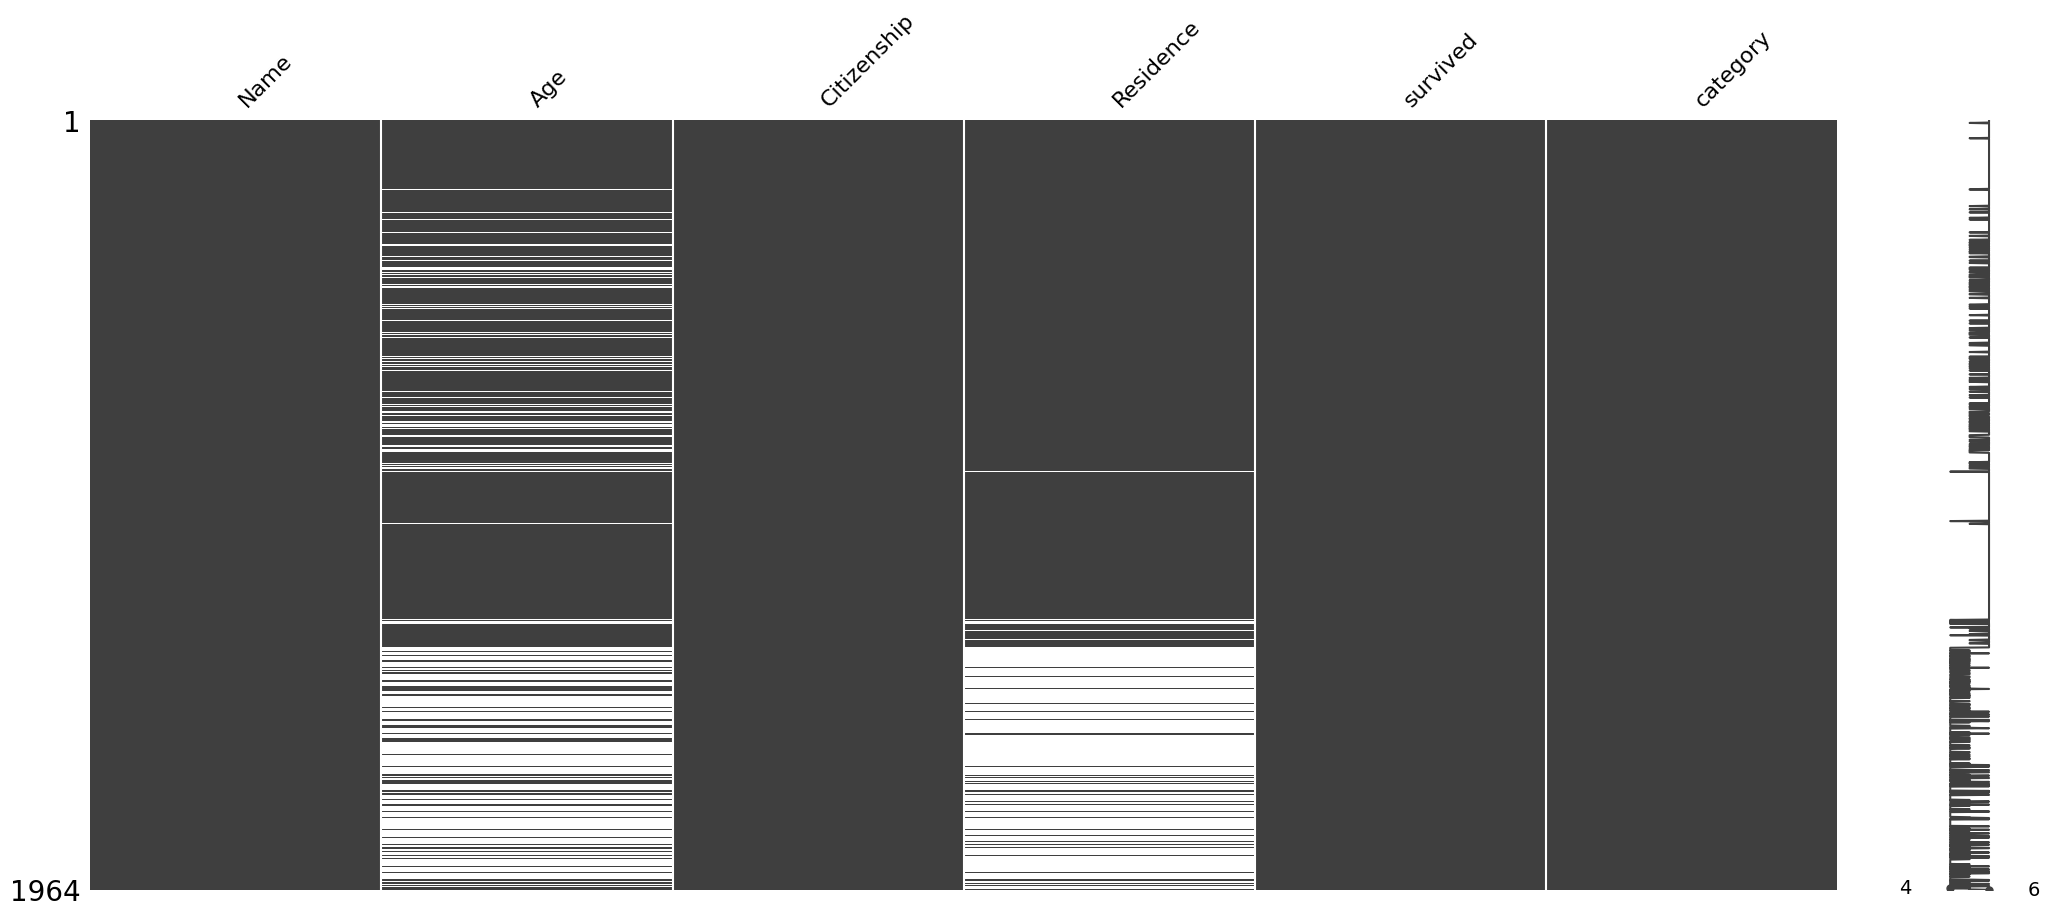

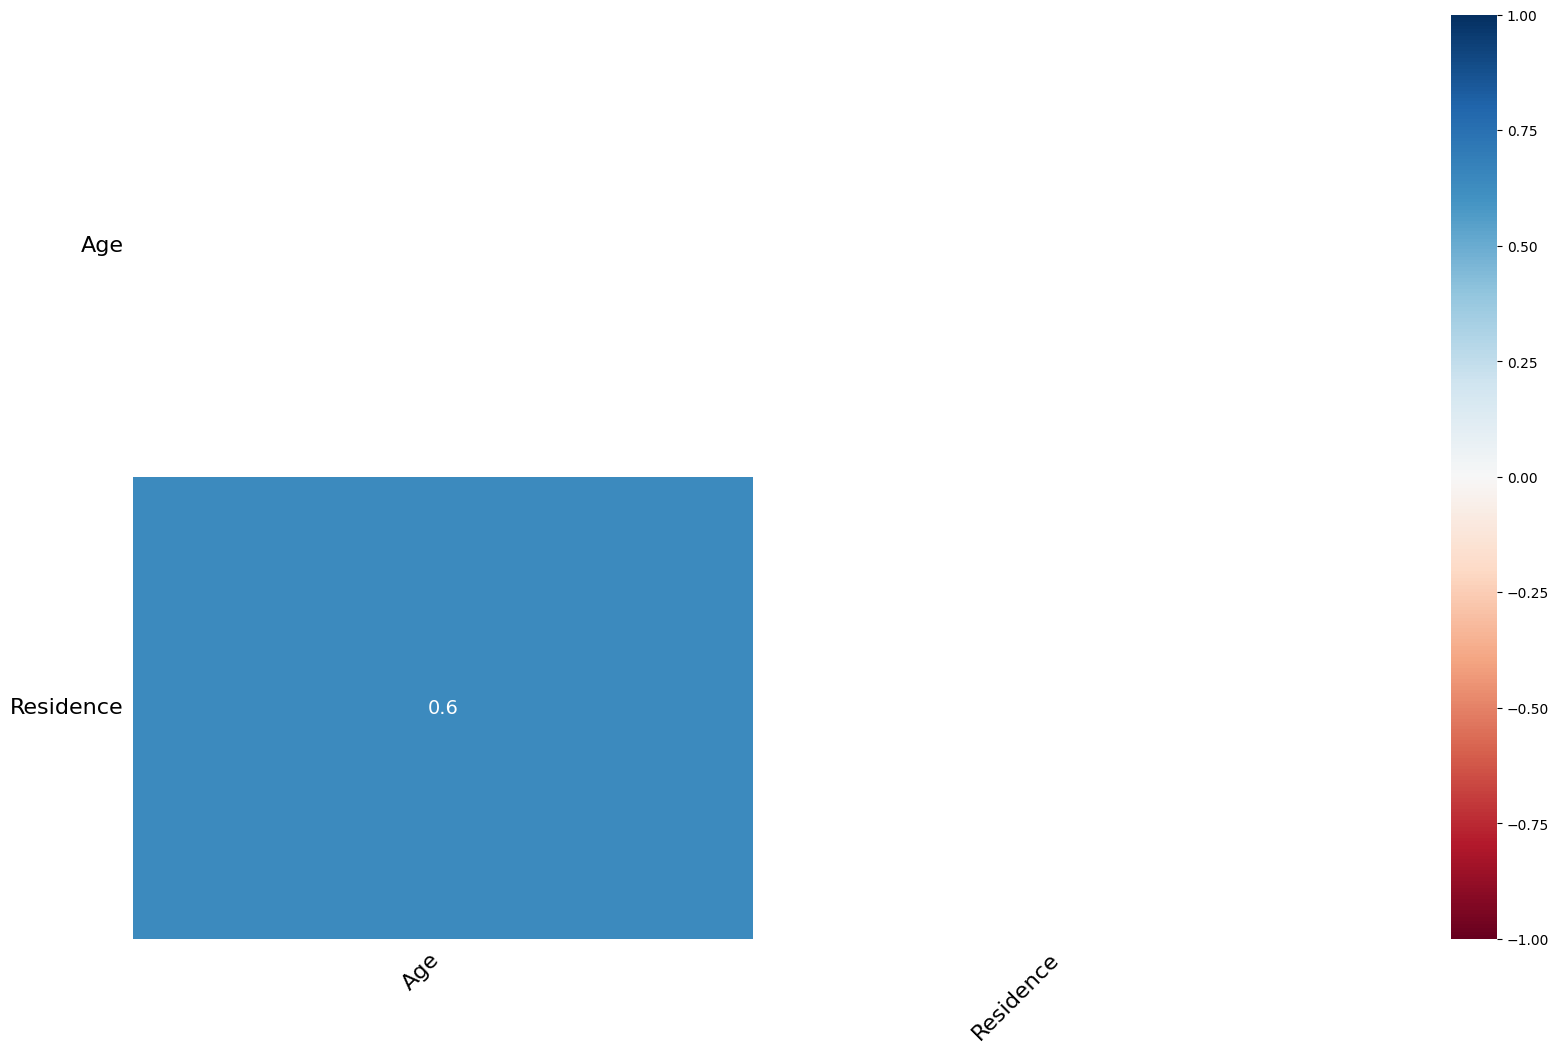

In [224]:
import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(df_lusitania)
plt.show()

msno.heatmap(df_lusitania)
plt.show()

In [225]:
df_lusitania["age_missing"] = df_lusitania["Age"].isna().astype(int)
pd.crosstab(df_lusitania["age_missing"], df_lusitania["category"])

category,band,deck_crew,engineering_crew,saloon_1st,second_cabin_2nd,third_class_3rd,victualling_crew
age_missing,,,,,,,
0,5,71,83,281,461,368,97
1,0,7,230,9,140,3,209


In [226]:
pd.crosstab(df_lusitania["category"], df_lusitania["age_missing"], normalize="index")

age_missing,0,1
category,,
band,1.000000,0.000000
deck_crew,0.910256,0.089744
engineering_crew,0.265176,0.734824
saloon_1st,0.968966,0.031034
second_cabin_2nd,0.767055,0.232945
third_class_3rd,0.991914,0.008086
victualling_crew,0.316993,0.683007


In [227]:
df_lusitania.drop(columns=['age_missing'], inplace= True)

L’analyse des proportions de valeurs manquantes montre une forte hétérogénéité selon les catégories. Les membres de l’équipage technique et du service présentent respectivement environ 74 % et 70 % d’âges manquants, alors que les passagers de première et troisième classe présentent moins de 6 % de valeurs manquantes. Cette différence marquée indique que la probabilité qu’un âge soit manquant dépend fortement du rôle et du statut social des individus. Le mécanisme de données manquantes n’est donc pas complètement aléatoire (MCAR) et est compatible avec un mécanisme au moins MAR, voire MNAR d’un point de vue historique. Cette observation justifie l’utilisation d’une imputation conditionnelle basée sur la catégorie plutôt qu’une imputation globale.

La proportion élevée d’âges manquants chez les membres d’équipage peut s’expliquer par des facteurs historiques. Contrairement aux passagers, les membres d’équipage étaient souvent recrutés comme travailleurs temporaires et faisaient l’objet d’un suivi administratif moins détaillé. Après la catastrophe, l’identification des victimes a également été plus difficile pour l’équipage, dont les proches étaient parfois absents ou éloignés géographiquement. Les archives historiques ont donc conservé moins d’informations démographiques pour ces individus. Cela suggère que les données manquantes reflètent des biais historiques et sociaux plutôt qu’un simple hasard statistique.

In [228]:
#Remplacement des valeurs manquantes age par la médiane 
df_lusitania["Age"] = pd.to_numeric(df_lusitania["Age"], errors="coerce")
df_lusitania.groupby("category")["Age"].median()
df_lusitania["Age"] = df_lusitania.groupby("category")["Age"]\
                                  .transform(lambda x: x.fillna(x.median()))

In [229]:
df_lusitania["Age"].isna().sum()

np.int64(0)

Les valeurs manquantes de l’âge ont été imputées à l’aide d’une médiane conditionnelle par catégorie. Cette approche est motivée par l’analyse du mécanisme de données manquantes, qui montre que l’âge est plus souvent absent pour certaines catégories d’équipage. Les valeurs restantes ont été remplacées par la médiane globale afin d’assurer l’absence de valeurs manquantes.

In [230]:
bins = [0, 12, 18, 35, 50, 100]
labels = ["Child", "Teen", "YoungAdult", "Adult", "Senior"]

df_lusitania["age_group"] = pd.cut(
    df_lusitania["Age"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# FEATURE ENGINEERING 

## Age

Afin de réduire le bruit de l’âge exact et d’améliorer la comparabilité entre catastrophes éloignées dans le temps, nous transformons également l’âge en groupes d’âge (age_group) représentant des étapes de vie (enfants, adolescents, jeunes adultes, adultes, seniors).

In [231]:
#On refait ce qu'on a fait plus tôt pour le 
bins = [0, 12, 18, 35, 50, 100]
labels = ["Child", "Teen", "YoungAdult", "Adult", "Senior"]

for df in [df_titanic, df_lusitania, df_estonia]:
    df["age_group"] = pd.cut(df["Age"], bins=bins, labels=labels, include_lowest=True)

# Vérif rapide
print(df_titanic["age_group"].value_counts(dropna=False))
print(df_estonia["age_group"].value_counts(dropna=False))

age_group
YoungAdult    459
Adult         190
Teen           87
Child          79
Senior         72
Name: count, dtype: int64
age_group
Senior        365
YoungAdult    292
Adult         290
Teen           31
Child          11
Name: count, dtype: int64


## Connectivité sociale 

Pour le Titanic, les données contiennent le nombre de frères/sœurs/conjoints (Siblings/Spouses Aboard) et le nombre de parents/enfants (Parents/Children Aboard). Ces variables permettent d’estimer la taille du groupe de voyage. Nous calculons la taille du groupe (group_size) comme la somme de ces variables plus la personne elle-même. Nous créons ensuite une variable binaire has_group indiquant si la personne voyage seule ou accompagnée

In [232]:
# CONNECTIVITÉ SOCIALE — TITANIC 

df_titanic["group_size"] = (
    1
    + df_titanic["Siblings/Spouses Aboard"]
    + df_titanic["Parents/Children Aboard"]
)

df_titanic["has_group"] = (df_titanic["group_size"] > 1).astype(int)

df_titanic[["group_size", "has_group"]].head()

,group_size,has_group
0,2,1
1,2,1
2,1,0
3,2,1
4,1,0


La variable de connectivité sociale est disponible uniquement pour le Titanic, où les informations familiales sont renseignées. Pour les autres catastrophes, ces informations sont absentes. Nous conservons néanmoins cette variable afin de maintenir un schéma de données cohérent entre catastrophes, ce qui illustre les défis liés à l’intégration de sources historiques hétérogènes.

In [233]:
# CONNECTIVITÉ SOCIALE — LUSITANIA

df_lusitania["group_size"] = 1
df_lusitania["has_group"] = 0

In [234]:
# CONNECTIVITÉ SOCIALE — ESTONIA

df_estonia["group_size"] = 1
df_estonia["has_group"] = 0

Afin d’intégrer des informations contextuelles externes (météo, caractéristiques du navire, contexte historique/économique) et de mieux gérer le décalage de distribution entre catastrophes séparées par plus de 80 ans, nous construisons une table de contexte au niveau “catastrophe” (une ligne par naufrage). Cette table contient des variables numériques et ordinales telles que les dimensions du navire (longueur, largeur, tirant d’eau, tonnage, capacité), des indicateurs de conditions au moment du naufrage (état de la mer codé sur une échelle ordinale, température de l’eau, nuit/jour), ainsi que des variables de contexte (paix/guerre, cause principale, importance économique approximative, choc réglementaire). Nous fusionnons ensuite cette table avec le dataset individuel (passagers/équipage) via la clé disaster. Cela permet au modèle d’exploiter un contexte commun à tous les individus d’une même catastrophe tout en conservant les variables individuelles (âge, sexe, rôle, etc.), et offre une base plus robuste pour l’apprentissage inter-catastrophes.

In [266]:
context_df = pd.DataFrame([
    {
        "disaster": "Titanic",
        "year": 1912,
        "wartime": 0,
        "sea_state": 0,            # très calme
        "night": 1,
        "ship_size": 3,            # grand
        "economic_importance": 3   # très élevée
    },
    {
        "disaster": "Lusitania",
        "year": 1915,
        "wartime": 1,
        "sea_state": 1,            # calme/modérée
        "night": 0,                # jour
        "ship_size": 3,            # grand
        "economic_importance": 3   # très élevée
    },
    {
        "disaster": "Estonia",
        "year": 1994,
        "wartime": 0,
        "sea_state": 3,            # tempête
        "night": 1,    
        "ship_size": 1,            # plus petit
        "economic_importance": 2   # élevée régionale
    }
])

display(context_df)


,disaster,year,wartime,sea_state,night,ship_size,economic_importance
0,Titanic,1912,0,0,1,3,3
1,Lusitania,1915,1,1,0,3,3
2,Estonia,1994,0,3,1,1,2


In [236]:
df_estonia['Country'].unique()

<StringArray>
[       'Sweden',       'Estonia',        'Latvia',        'Russia',
       'Germany',       'Finland', 'Great Britain',       'Morocco',
       'Denmark',        'France',   'Netherlands',        'Norway',
     'Lithuania',       'Nigeria',        'Canada',       'Belarus']
Length: 16, dtype: str

In [237]:
df_lusitania['Citizenship'].unique()

<StringArray>
[                          'USA',                       'British',
            'British (Canadian)',                         'Cuban',
                         'Greek',                   'British/USA',
                       'Belgian',             'British (English)',
                       'Swedish',                        'French',
               'British (Irish)',                   'USA/British',
                       'Mexican',                        'Danish',
                         'Swiss',                 'British/Dutch',
                       'Russian',                       'Italian',
           'British (Irish)/USA',                       'Spanish',
                     'Argentine',            'British (Scottish)',
        'Russian or Belgian (?)',                       'Persian',
             'Russian (Finnish)',         'Russian (Finnish)/USA',
              'Russian (Polish)',              'British (Indian)',
                        'Brtish',          'Russ

In [238]:
country_map = {
    "british": "Great Britain",
    "england": "Great Britain",
    "irish": "Ireland",
    "scottish": "Great Britain",
    "welsh": "Great Britain",
    "manx": "Great Britain",
    "cornish": "Great Britain",

    "usa": "USA",
    "american": "USA",
    "canadian": "Canada",

    "russian": "Russia",
    "ukrainian": "Ukraine",
    "polish": "Poland",

    "german": "Germany",
    "french": "France",
    "danish": "Denmark",
    "swedish": "Sweden",
    "norwegian": "Norway",
    "dutch": "Netherlands",
    "belgian": "Belgium",
    "finnish": "Finland",
    "italian": "Italy",
    "spanish": "Spain",
    "greek": "Greece",
    "mexican": "Mexico",
    "brazilian": "Brazil",
    "argentine": "Argentina",
    "persian": "Iran",
    "cuban": "Cuba",
    "swiss": "Switzerland",
}

In [239]:
# NORMALISER texte
df_lusitania["Citizenship"] = df_lusitania["Citizenship"].str.lower().str.strip()

def map_region(c):
    if pd.isna(c):
        return "unknown"
    
    # UK / Ireland
    if any(x in c for x in ["british","irish","welsh","scottish","manx","cornish","jamaican","maltese","indian"]):
        return "uk_ireland"
    
    # USA
    if "usa" in c:
        return "usa"
    
    # Europe (hors UK)
    if any(x in c for x in [
        "swedish","french","belgian","danish","swiss","dutch","russian",
        "italian","spanish","norwegian","german","greek","persian","finnish","polish","ukrainian"
    ]):
        return "europe"
    
    # Amérique latine
    if any(x in c for x in ["mexican","argentine","brazilian","cuban"]):
        return "latin_america"
    
    return "other"

df_lusitania["nationality_region"] = df_lusitania["Citizenship"].apply(map_region)

df_lusitania["nationality_region"].value_counts()

nationality_region
uk_ireland       1633
usa               199
europe            126
latin_america       5
other               1
Name: count, dtype: int64

In [240]:
# NORMALISER
df_estonia["Country"] = df_estonia["Country"].str.lower().str.strip()

def map_region_estonia(c):
    if pd.isna(c):
        return "unknown"
    
    # Pays nordiques / Baltique (majorité Estonia)
    if c in ["sweden","estonia","finland","norway","denmark"]:
        return "nordic_baltic"
    
    # Europe
    if c in ["germany","latvia","lithuania","poland","russia","uk","france"]:
        return "europe"
    
    return "other"

df_estonia["nationality_region"] = df_estonia["Country"].apply(map_region_estonia)

df_estonia["nationality_region"].value_counts()

nationality_region
nordic_baltic    925
europe            55
other              9
Name: count, dtype: int64

In [241]:
#Maintenant on change on homogénise la colonne sexe dans le estonia et le titanic
df_estonia["Sex"] = df_estonia["Sex"].map({
    "M": "male",
    "F": "female"
})

In [242]:
df_estonia["Sex"].unique()
df_titanic["Sex"].unique()

<StringArray>
['male', 'female']
Length: 2, dtype: str

In [243]:
#On crée la colonne name qui combine le nom et prénom pour le estonia pour que ce soit que les deux autres datasets
df_estonia["Name"] = df_estonia["Firstname"] + " " + df_estonia["Lastname"]
df_estonia.drop(columns=["Firstname", "Lastname"], inplace=True)

In [244]:
df_estonia['Category'].unique()

<StringArray>
['P', 'C']
Length: 2, dtype: str

In [245]:
df_lusitania['category'].unique()

<StringArray>
[      'saloon_1st', 'second_cabin_2nd',  'third_class_3rd',
        'deck_crew', 'victualling_crew', 'engineering_crew',
             'band']
Length: 7, dtype: str

In [246]:
df_titanic['Pclass'].unique()

array([3, 1, 2])

In [247]:
lusitania_class_map = {
    "saloon_1st": "First",
    "second_cabin_2nd": "Second",
    "third_class_3rd": "Third",
    "deck_crew": "Crew",
    "victualling_crew": "Crew",
    "engineering_crew": "Crew",
    "band": "Crew",
}

df_lusitania["travel_class"] = df_lusitania["category"].map(lusitania_class_map)

In [248]:
df_titanic["travel_class"] = df_titanic["Pclass"].map({1:"First", 2:"Second", 3:"Third"})

In [249]:
df_lusitania.drop(columns=["Residence", "category", "Citizenship"], inplace=True)
df_lusitania.rename(columns={"survived": "Survived"}, inplace=True)

In [250]:
df_estonia["travel_class"] = df_estonia["Category"].map({
    "P": "Passenger",
    "C": "Crew"
})

In [251]:
df_lusitania

,Name,Age,Survived,age_group,group_size,has_group,nationality_region,travel_class
0,"ADAMS, Mr. Arthur Henry",46.0,0,Adult,1,0,usa,First
1,"ADAMS, Mr. William McMillan(son of Arthur Adams)",19.0,1,YoungAdult,1,0,usa,First
2,"ADAMS, Mr. Henry",58.0,0,Senior,1,0,uk_ireland,First
3,"ADAMS, Mrs. Henry (Annie Elizabeth Macnutt)",46.0,1,Adult,1,0,uk_ireland,First
4,"ALLAN, Lady Hugh Montagu (Marguerite Ethel Mac...",42.0,1,Adult,1,0,uk_ireland,First
...,...,...,...,...,...,...,...,...
1959,"CAMERON, Mr. Charles W.",38.0,0,Adult,1,0,uk_ireland,Crew
1960,"CARR-JONES, Mr. E.",37.0,0,Adult,1,0,uk_ireland,Crew
1961,"DRAKEFORD, Mr. Ernest Dixon",30.0,1,YoungAdult,1,0,uk_ireland,Crew
1962,"HAWKINS, Mr. Thomas Handel",27.0,1,YoungAdult,1,0,uk_ireland,Crew


In [252]:
df_estonia.drop(columns=["PassengerId", "Country"], inplace=True)

In [253]:
df_estonia

,Sex,Age,Category,Survived,age_group,group_size,has_group,nationality_region,Name,travel_class
0,male,62,P,0,Senior,1,0,nordic_baltic,ARVID KALLE AADLI,Passenger
1,female,22,C,0,YoungAdult,1,0,nordic_baltic,LEA AALISTE,Crew
2,female,21,C,0,YoungAdult,1,0,nordic_baltic,AIRI AAVASTE,Crew
3,male,53,C,0,Senior,1,0,nordic_baltic,JURI AAVIK,Crew
4,female,55,P,0,Senior,1,0,nordic_baltic,BRITTA ELISABET AHLSTROM,Passenger
...,...,...,...,...,...,...,...,...,...,...
984,female,60,P,0,Senior,1,0,nordic_baltic,ANNA INGRID BIRGITTA OSTROM,Passenger
985,male,34,P,1,YoungAdult,1,0,nordic_baltic,ELMAR MIKAEL OUN,Passenger
986,male,77,P,0,Senior,1,0,nordic_baltic,ENN QUNAPUU,Passenger
987,female,87,P,0,Senior,1,0,nordic_baltic,LY GUNAPUU,Passenger


In [257]:
#On va mettre tous les dataset dans le même ordre 

final_order = [
    "Name",
    "Sex", 
    "Age",
    "age_group",
    "group_size",
    "has_group",
    "nationality_region",
    "travel_class",
    "Survived"
]

df_estonia = df_estonia[final_order]
df_lusitania= df_lusitania[final_order]


In [260]:
df_lusitania["Sex"] = "Not mentioned"
df_lusitania = df_lusitania[final_order]

In [261]:
df_lusitania

,Name,Sex,Age,age_group,group_size,has_group,nationality_region,travel_class,Survived
0,"ADAMS, Mr. Arthur Henry",Not mentioned,46.0,Adult,1,0,usa,First,0
1,"ADAMS, Mr. William McMillan(son of Arthur Adams)",Not mentioned,19.0,YoungAdult,1,0,usa,First,1
2,"ADAMS, Mr. Henry",Not mentioned,58.0,Senior,1,0,uk_ireland,First,0
3,"ADAMS, Mrs. Henry (Annie Elizabeth Macnutt)",Not mentioned,46.0,Adult,1,0,uk_ireland,First,1
4,"ALLAN, Lady Hugh Montagu (Marguerite Ethel Mac...",Not mentioned,42.0,Adult,1,0,uk_ireland,First,1
...,...,...,...,...,...,...,...,...,...
1959,"CAMERON, Mr. Charles W.",Not mentioned,38.0,Adult,1,0,uk_ireland,Crew,0
1960,"CARR-JONES, Mr. E.",Not mentioned,37.0,Adult,1,0,uk_ireland,Crew,0
1961,"DRAKEFORD, Mr. Ernest Dixon",Not mentioned,30.0,YoungAdult,1,0,uk_ireland,Crew,1
1962,"HAWKINS, Mr. Thomas Handel",Not mentioned,27.0,YoungAdult,1,0,uk_ireland,Crew,1


In [256]:
df_estonia

,Name,Sex,Age,age_group,group_size,has_group,nationality_region,travel_class,Survived
0,ARVID KALLE AADLI,male,62,Senior,1,0,nordic_baltic,Passenger,0
1,LEA AALISTE,female,22,YoungAdult,1,0,nordic_baltic,Crew,0
2,AIRI AAVASTE,female,21,YoungAdult,1,0,nordic_baltic,Crew,0
3,JURI AAVIK,male,53,Senior,1,0,nordic_baltic,Crew,0
4,BRITTA ELISABET AHLSTROM,female,55,Senior,1,0,nordic_baltic,Passenger,0
...,...,...,...,...,...,...,...,...,...
984,ANNA INGRID BIRGITTA OSTROM,female,60,Senior,1,0,nordic_baltic,Passenger,0
985,ELMAR MIKAEL OUN,male,34,YoungAdult,1,0,nordic_baltic,Passenger,1
986,ENN QUNAPUU,male,77,Senior,1,0,nordic_baltic,Passenger,0
987,LY GUNAPUU,female,87,Senior,1,0,nordic_baltic,Passenger,0


In [264]:
#Nettoyage du titanic

df_titanic.drop(
    columns=["Pclass", "Siblings/Spouses Aboard", "Parents/Children Aboard"],
    inplace=True
)
df_titanic["nationality_region"] = "Not mentioned"

final_order = [
    "Name",
    "Sex",
    "Age",
    "age_group",
    "group_size",
    "has_group",
    "nationality_region",
    "travel_class",
    "Fare",
    "Survived"
]

df_titanic = df_titanic[final_order]

In [265]:
df_titanic

,Name,Sex,Age,age_group,group_size,has_group,nationality_region,travel_class,Fare,Survived
0,Mr. Owen Harris Braund,male,22.0,YoungAdult,2,1,Not mentioned,Third,7.2500,0
1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,Adult,2,1,Not mentioned,First,71.2833,1
2,Miss. Laina Heikkinen,female,26.0,YoungAdult,1,0,Not mentioned,Third,7.9250,1
3,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,YoungAdult,2,1,Not mentioned,First,53.1000,1
4,Mr. William Henry Allen,male,35.0,YoungAdult,1,0,Not mentioned,Third,8.0500,0
...,...,...,...,...,...,...,...,...,...,...
882,Rev. Juozas Montvila,male,27.0,YoungAdult,1,0,Not mentioned,Second,13.0000,0
883,Miss. Margaret Edith Graham,female,19.0,YoungAdult,1,0,Not mentioned,First,30.0000,1
884,Miss. Catherine Helen Johnston,female,7.0,Child,4,1,Not mentioned,Third,23.4500,0
885,Mr. Karl Howell Behr,male,26.0,YoungAdult,1,0,Not mentioned,First,30.0000,1


# Construction d'un grand dataset harmonisé

In [267]:
df_titanic["disaster"] = "Titanic"
df_lusitania["disaster"] = "Lusitania"
df_estonia["disaster"] = "Estonia"

In [268]:
df_passengers = pd.concat(
    [df_titanic, df_lusitania, df_estonia],
    ignore_index=True
)

In [270]:
df_final = df_passengers.merge(
    context_df,
    on="disaster",
    how="left"
)

In [271]:
df_final

,Name,Sex,Age,age_group,group_size,has_group,nationality_region,travel_class,Fare,Survived,disaster,year,wartime,sea_state,night,ship_size,economic_importance
0,Mr. Owen Harris Braund,male,22.0,YoungAdult,2,1,Not mentioned,Third,7.2500,0,Titanic,1912,0,0,1,3,3
1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,Adult,2,1,Not mentioned,First,71.2833,1,Titanic,1912,0,0,1,3,3
2,Miss. Laina Heikkinen,female,26.0,YoungAdult,1,0,Not mentioned,Third,7.9250,1,Titanic,1912,0,0,1,3,3
3,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,YoungAdult,2,1,Not mentioned,First,53.1000,1,Titanic,1912,0,0,1,3,3
4,Mr. William Henry Allen,male,35.0,YoungAdult,1,0,Not mentioned,Third,8.0500,0,Titanic,1912,0,0,1,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3835,ANNA INGRID BIRGITTA OSTROM,female,60.0,Senior,1,0,nordic_baltic,Passenger,NaN,0,Estonia,1994,0,3,1,1,2
3836,ELMAR MIKAEL OUN,male,34.0,YoungAdult,1,0,nordic_baltic,Passenger,NaN,1,Estonia,1994,0,3,1,1,2
3837,ENN QUNAPUU,male,77.0,Senior,1,0,nordic_baltic,Passenger,NaN,0,Estonia,1994,0,3,1,1,2
3838,LY GUNAPUU,female,87.0,Senior,1,0,nordic_baltic,Passenger,NaN,0,Estonia,1994,0,3,1,1,2


In [272]:
df_final.head()
df_final.shape
df_final["disaster"].value_counts()

disaster
Lusitania    1964
Estonia       989
Titanic       887
Name: count, dtype: int64

In [273]:
df_viz = df_final.copy()

# 3) Créer un MultiIndex (disaster + id dans le dataframe)
df_viz = df_viz.reset_index(drop=True)
df_viz["passenger_id"] = df_viz.groupby("disaster").cumcount()

In [275]:
df_viz = df_viz.set_index(["disaster", "passenger_id"]).sort_index()

In [276]:
df_viz

Name     Sex   Age  \
disaster passenger_id                                                 
Estonia  0                          ARVID KALLE AADLI    male  62.0   
         1                                LEA AALISTE  female  22.0   
         2                               AIRI AAVASTE  female  21.0   
         3                                 JURI AAVIK    male  53.0   
         4                   BRITTA ELISABET AHLSTROM  female  55.0   
...                                               ...     ...   ...   
Titanic  882                     Rev. Juozas Montvila    male  27.0   
         883              Miss. Margaret Edith Graham  female  19.0   
         884           Miss. Catherine Helen Johnston  female   7.0   
         885                     Mr. Karl Howell Behr    male  26.0   
         886                       Mr. Patrick Dooley    male  32.0   

                        age_group  group_size  has_group nationality_region  \
disaster passenger_id                                                         
Estonia  0                 Senior           1          0      nordic_baltic   
         1             YoungAdult           1          0      nordic_baltic   
         2             YoungAdult           1          0      nordic_baltic   
         3                 Senior           1          0      nordic_baltic   
         4                 Senior           1          0      nordic_baltic   
...                           ...         ...        ...                ...   
Titanic  882           YoungAdult           1          0      Not mentioned   
         883           YoungAdult           1          0      Not mentioned   
         884                Child           4          1      Not mentioned   
         885           YoungAdult           1          0      Not mentioned   
         886           YoungAdult           1          0      Not mentioned   

                      travel_class   Fare  Survived  year  wartime  sea_state  \
disaster passenger_id                                                           
Estonia  0               Passenger    NaN         0  1994        0          3   
         1                    Crew    NaN         0  1994        0          3   
         2                    Crew    NaN         0  1994        0          3   
         3                    Crew    NaN         0  1994        0          3   
         4               Passenger    NaN         0  1994        0          3   
...                            ...    ...       ...   ...      ...        ...   
Titanic  882                Second  13.00         0  1912        0          0   
         883                 First  30.00         1  1912        0          0   
         884                 Third  23.45         0  1912        0          0   
         885                 First  30.00         1  1912        0          0   
         886                 Third   7.75         0  1912        0          0   

                       night  ship_size  economic_importance  
disaster passenger_id                                         
Estonia  0                 1          1                    2  
         1                 1          1                    2  
         2                 1          1                    2  
         3                 1          1                    2  
         4                 1          1                    2  
...                      ...        ...                  ...  
Titanic  882               1          3                    3  
         883               1          3                    3  
         884               1          3                    3  
         885               1          3                    3  
         886               1          3                    3  

[3840 rows x 16 columns]

In [279]:
import os

base_path = r"C:\Users\noura\ml-disaster-survival-project\data\processed"
os.makedirs(base_path, exist_ok=True)

In [280]:
df_final.to_csv(
    r"C:\Users\noura\ml-disaster-survival-project\data\processed\disaster_ml_dataset.csv",
    index=False
)
df_viz.to_csv(
    r"C:\Users\noura\ml-disaster-survival-project\data\processed\disaster_viz_dataset.csv"
)

In [281]:
df_viz

Name     Sex   Age  \
disaster passenger_id                                                 
Estonia  0                          ARVID KALLE AADLI    male  62.0   
         1                                LEA AALISTE  female  22.0   
         2                               AIRI AAVASTE  female  21.0   
         3                                 JURI AAVIK    male  53.0   
         4                   BRITTA ELISABET AHLSTROM  female  55.0   
...                                               ...     ...   ...   
Titanic  882                     Rev. Juozas Montvila    male  27.0   
         883              Miss. Margaret Edith Graham  female  19.0   
         884           Miss. Catherine Helen Johnston  female   7.0   
         885                     Mr. Karl Howell Behr    male  26.0   
         886                       Mr. Patrick Dooley    male  32.0   

                        age_group  group_size  has_group nationality_region  \
disaster passenger_id                                                         
Estonia  0                 Senior           1          0      nordic_baltic   
         1             YoungAdult           1          0      nordic_baltic   
         2             YoungAdult           1          0      nordic_baltic   
         3                 Senior           1          0      nordic_baltic   
         4                 Senior           1          0      nordic_baltic   
...                           ...         ...        ...                ...   
Titanic  882           YoungAdult           1          0      Not mentioned   
         883           YoungAdult           1          0      Not mentioned   
         884                Child           4          1      Not mentioned   
         885           YoungAdult           1          0      Not mentioned   
         886           YoungAdult           1          0      Not mentioned   

                      travel_class   Fare  Survived  year  wartime  sea_state  \
disaster passenger_id                                                           
Estonia  0               Passenger    NaN         0  1994        0          3   
         1                    Crew    NaN         0  1994        0          3   
         2                    Crew    NaN         0  1994        0          3   
         3                    Crew    NaN         0  1994        0          3   
         4               Passenger    NaN         0  1994        0          3   
...                            ...    ...       ...   ...      ...        ...   
Titanic  882                Second  13.00         0  1912        0          0   
         883                 First  30.00         1  1912        0          0   
         884                 Third  23.45         0  1912        0          0   
         885                 First  30.00         1  1912        0          0   
         886                 Third   7.75         0  1912        0          0   

                       night  ship_size  economic_importance  
disaster passenger_id                                         
Estonia  0                 1          1                    2  
         1                 1          1                    2  
         2                 1          1                    2  
         3                 1          1                    2  
         4                 1          1                    2  
...                      ...        ...                  ...  
Titanic  882               1          3                    3  
         883               1          3                    3  
         884               1          3                    3  
         885               1          3                    3  
         886               1          3                    3  

[3840 rows x 16 columns]